# Machine Learning Models, Hyperparameter Tuning, and MLflow Tracking

## Objective

This notebook continues the forecasting workflow from the previous notebooks.

The cleaned daily time series was prepared in Notebook 01, and the feature-engineered dataset was created in Notebook 02. Statistical forecasting models were trained and compared in Notebook 03.

In this notebook, we complete the feature-based machine learning modeling approach and then apply methods: HyperOpt for hyperparameter tuning and MLflow for experiment tracking.

The main goals are to:
- train baseline regression models using the feature-engineered dataset,
- evaluate all models on the same official test period,
- tune selected models using HyperOpt,
- log experiments, parameters, metrics, and models with MLflow,
- compare tuned models,
- select a champion model,
- save the champion model for later use in the Week 4 Streamlit app.

## Evaluation Setup

All models are evaluated using the same time periods:

- Training period: 2013-01-01 to 2013-12-31
- Test period: 2014-01-01 to 2014-03-31

The same metrics are used for all models:

- MAE
- RMSE
- MAPE
- R²

# 1. Environment Setup

In [22]:
# Core libraries
import os
import json
import joblib
import warnings
import time

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# XGBoost
import xgboost
from xgboost import XGBRegressor

# LSTM / deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Hyperparameter tuning
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# MLflow tracking
import mlflow
import mlflow.sklearn

pd.set_option("display.max_columns", None)

print("Environment setup completed.")
print("XGBoost version:", xgboost.__version__)
print("TensorFlow version:", tf.__version__)

Environment setup completed.
XGBoost version: 3.2.0
TensorFlow version: 2.21.0


# 2. Load the Feature-Engineered Dataset

The feature-engineered dataset was created in Notebook 02. It contains the cleaned daily sales time series together with calendar, lag, rolling, oil, and holiday features.

In this notebook, this dataset is used to train regression-based machine learning models.

In [2]:
# Load the feature-engineered dataset

feature_data_path = "../../data/processed/feature_engineered_timeseries.csv"

df = pd.read_csv(feature_data_path, parse_dates=["date"])

print("Feature-engineered dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())
display(df.tail())

Feature-engineered dataset loaded successfully.
Shape: (424, 25)


,date,unit_sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_price_interpolated,oil_lag_1,oil_rolling_7d_mean,is_national_holiday,is_regional_holiday,is_local_holiday
0,2013-02-01,401.0,2013,2,1,4,1,5,0,1,0,282.0,389.0,60.0,582.0,454.571429,497.071429,520.833333,154.059358,97.46,97.65,96.378571,0,0,0
1,2013-02-02,775.0,2013,2,2,5,1,5,1,0,0,401.0,697.0,667.0,310.0,456.285714,521.428571,514.800000,153.272866,97.46,97.46,96.708571,0,0,0
2,2013-02-03,855.0,2013,2,3,6,1,5,1,0,0,775.0,616.0,1090.0,338.0,467.428571,529.142857,530.300000,174.986530,97.46,97.46,97.038571,0,0,0
3,2013-02-04,411.0,2013,2,4,0,1,6,0,0,0,855.0,318.0,760.0,654.0,501.571429,512.357143,547.533333,224.981375,96.21,97.46,97.368571,0,0,0
4,2013-02-05,272.0,2013,2,5,1,1,6,0,0,0,411.0,393.0,461.0,979.0,514.857143,487.428571,539.433333,214.852219,96.68,96.21,97.405714,0,0,0


,date,unit_sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_price_interpolated,oil_lag_1,oil_rolling_7d_mean,is_national_holiday,is_regional_holiday,is_local_holiday
419,2014-03-27,328.0,2014,3,27,3,1,13,0,0,0,432.0,139.0,254.0,453.0,422.857143,407.285714,449.700000,152.001566,101.25,100.61,99.987143,0,0,0
420,2014-03-28,523.0,2014,3,28,4,1,13,0,0,0,328.0,456.0,243.0,388.0,449.857143,412.571429,445.533333,101.609430,101.73,101.25,100.211429,0,0,0
421,2014-03-29,647.0,2014,3,29,5,1,13,1,0,0,523.0,567.0,535.0,587.0,459.428571,432.571429,450.033333,105.370548,101.73,101.73,100.462857,0,0,0
422,2014-03-30,599.0,2014,3,30,6,1,13,1,0,0,647.0,603.0,726.0,346.0,470.857143,440.571429,452.033333,122.007416,101.73,101.73,100.714286,0,0,0
423,2014-03-31,415.0,2014,3,31,0,1,14,0,0,1,599.0,371.0,285.0,714.0,470.285714,431.500000,460.466667,121.292641,101.57,101.73,100.965714,0,0,0


In [3]:
# Validate the feature-engineered dataset

print("Feature-engineered dataset validation")
print("-" * 50)

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nShape:")
print(df.shape)

print("\nMissing values:")
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])

print("\nDuplicate dates:")
print(df["date"].duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())

Feature-engineered dataset validation
--------------------------------------------------
Date range:
2013-02-01 00:00:00 to 2014-03-31 00:00:00

Shape:
(424, 25)

Missing values:
Series([], dtype: int64)

Duplicate dates:
0

Columns:
['date', 'unit_sales', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std', 'oil_price_interpolated', 'oil_lag_1', 'oil_rolling_7d_mean', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday']


# 3. Define Target, Features, and Train/Test Split

The target variable is `unit_sales`.

The feature columns include calendar features, lag features, rolling statistics, oil-related features, and holiday flags. The `date` column is used only for splitting the data and is not used directly as a model feature.

The same official evaluation period is used as in the statistical modeling notebook:

- Training period: 2013-01-01 to 2013-12-31
- Test period: 2014-01-01 to 2014-03-31

Because the feature-engineered dataset starts on 2013-02-01 after lag and rolling feature creation, the effective ML training period starts from the first available feature-complete date.

In [4]:
# Define target and feature columns

target_col = "unit_sales"

feature_cols = [
    col for col in df.columns
    if col not in ["date", target_col]
]

print("Target column:", target_col)
print("Number of feature columns:", len(feature_cols))
print("Feature columns:")
print(feature_cols)

Target column: unit_sales
Number of feature columns: 23
Feature columns:
['year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std', 'oil_price_interpolated', 'oil_lag_1', 'oil_rolling_7d_mean', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday']


In [5]:
# Define official train/test periods

TRAIN_START = "2013-01-01"
TRAIN_END = "2013-12-31"
TEST_START = "2014-01-01"
TEST_END = "2014-03-31"

train_df = df[(df["date"] >= TRAIN_START) & (df["date"] <= TRAIN_END)].copy()
test_df = df[(df["date"] >= TEST_START) & (df["date"] <= TEST_END)].copy()

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTarget train shape:", y_train.shape)
print("Target test shape:", y_test.shape)

Train date range: 2013-02-01 00:00:00 to 2013-12-31 00:00:00
Test date range: 2014-01-01 00:00:00 to 2014-03-31 00:00:00

Train shape: (334, 23)
Test shape: (90, 23)

Target train shape: (334,)
Target test shape: (90,)


# 4. Define Evaluation Function

To compare all machine learning models fairly, the same evaluation metrics are used for every model.

The metrics are:
- MAE
- RMSE
- MAPE
- R²

RMSE will be used as the main comparison metric because it penalizes larger forecast errors more strongly.

In [6]:
# Define a reusable evaluation function

def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate a regression model using common forecasting metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)

    results = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

    print(f"{model_name} — Evaluation Metrics")
    print("-" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R²   : {r2:.4f}")
    print()

    return results

# 5. Train Baseline Machine Learning Models

Before applying hyperparameter tuning, several baseline regression models are trained on the feature-engineered dataset.

The baseline models include simple linear models and tree-based models:

- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

XGBoost is included because it follows the instructor workflow and is often effective for tabular feature-based forecasting.

All models are trained on the same training period and evaluated on the same January–March 2014 test period using the common evaluation function.

In [7]:
# Train and evaluate baseline machine learning models

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        n_jobs=-1
    )
}

baseline_results = []
baseline_predictions = {}
trained_baseline_models = {}

for model_name, model in baseline_models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    predictions = np.clip(predictions, 0, None)

    baseline_predictions[model_name] = predictions
    trained_baseline_models[model_name] = model

    result = evaluate_model(model_name, y_test, predictions)
    baseline_results.append(result)

print("Baseline model training completed.")

Training Linear Regression...
Linear Regression — Evaluation Metrics
----------------------------------------
MAE  : 98.01
RMSE : 145.29
MAPE : 21.92%
R²   : 0.3726

Training Ridge Regression...
Ridge Regression — Evaluation Metrics
----------------------------------------
MAE  : 98.69
RMSE : 145.70
MAPE : 22.11%
R²   : 0.3690

Training Random Forest...
Random Forest — Evaluation Metrics
----------------------------------------
MAE  : 98.83
RMSE : 143.79
MAPE : 22.33%
R²   : 0.3855

Training Gradient Boosting...
Gradient Boosting — Evaluation Metrics
----------------------------------------
MAE  : 102.79
RMSE : 147.02
MAPE : 23.42%
R²   : 0.3575

Training XGBoost...
XGBoost — Evaluation Metrics
----------------------------------------
MAE  : 103.84
RMSE : 148.35
MAPE : 23.86%
R²   : 0.3459

Baseline model training completed.


# 6. Compare Baseline Machine Learning Models

The baseline machine learning models are compared using the same evaluation metrics.

This comparison helps identify which models are already strong before hyperparameter tuning.

In [8]:
# Create baseline comparison table

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df = baseline_results_df.round({
    "MAE": 2,
    "RMSE": 2,
    "MAPE": 2,
    "R2": 4
})

baseline_results_df = baseline_results_df.sort_values("RMSE").reset_index(drop=True)

display(baseline_results_df)

print("Best baseline model by RMSE:")
print(baseline_results_df.loc[0, "Model"])

,Model,MAE,RMSE,MAPE,R2
0,Random Forest,98.83,143.79,22.33,0.3855
1,Linear Regression,98.01,145.29,21.92,0.3726
2,Ridge Regression,98.69,145.70,22.11,0.3690
3,Gradient Boosting,102.79,147.02,23.42,0.3575
4,XGBoost,103.84,148.35,23.86,0.3459


Best baseline model by RMSE:
Random Forest


The baseline machine learning results show that Random Forest achieved the lowest RMSE among the initial regression models.

However, the differences between the models are relatively small. Linear Regression achieved a slightly lower MAE and MAPE, while Random Forest performed best according to RMSE, the main comparison metric used in this notebook.

XGBoost did not outperform the simpler models with the initial default-style parameters. This suggests that hyperparameter tuning may be important before drawing a final conclusion about the strongest machine learning model.

# 7. Visualize Baseline Machine Learning Forecasts

The baseline model forecasts are plotted against the actual test values.

This visual comparison helps show whether the models capture the overall sales pattern and where they struggle, especially around sharp sales peaks or drops.

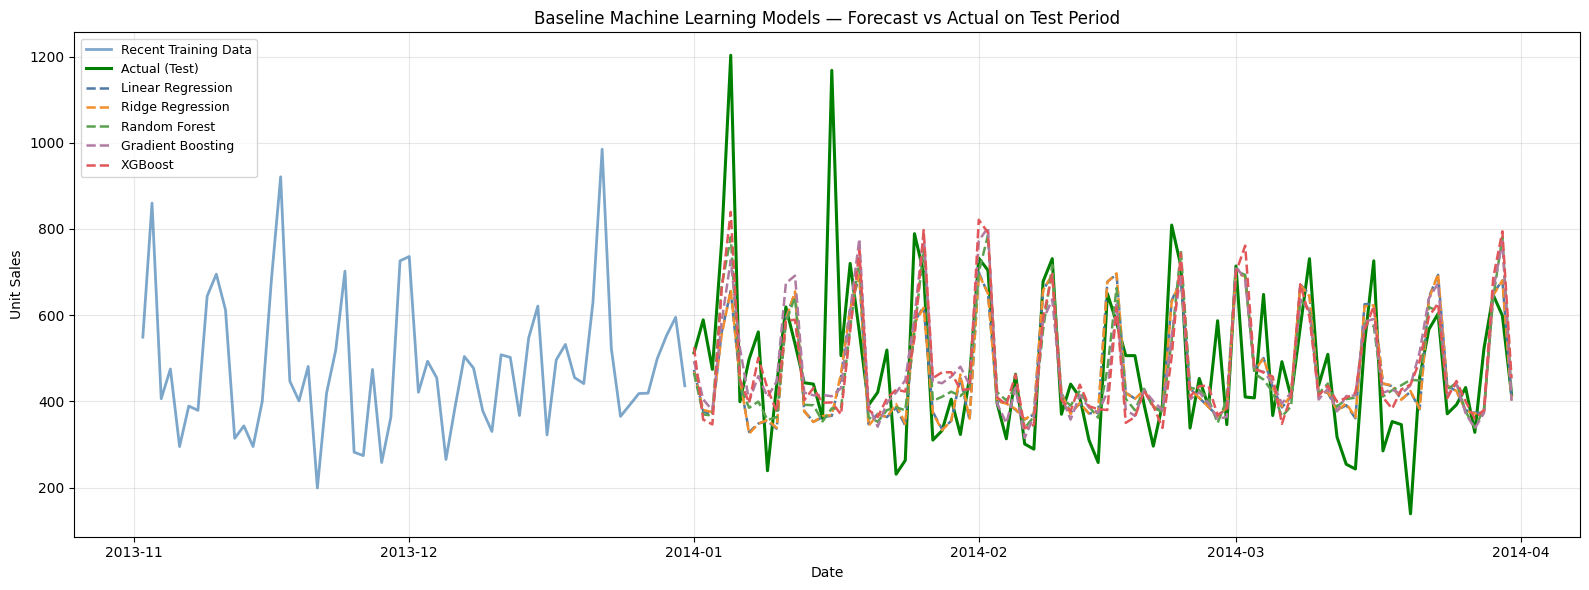

In [9]:
# Plot baseline machine learning forecasts against actual test values

plt.figure(figsize=(16, 6))

plt.plot(
    train_df["date"].iloc[-60:],
    y_train.iloc[-60:],
    label="Recent Training Data",
    color="steelblue",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    test_df["date"],
    y_test,
    label="Actual (Test)",
    color="green",
    linewidth=2.2
)

baseline_color_map = {
    "Linear Regression": "#4E79A7",
    "Ridge Regression": "#F28E2B",
    "Random Forest": "#59A14F",
    "Gradient Boosting": "#B07AA1",
    "XGBoost": "#E15759"
}

for model_name, predictions in baseline_predictions.items():
    plt.plot(
        test_df["date"],
        predictions,
        label=model_name,
        color=baseline_color_map.get(model_name),
        linewidth=1.8,
        linestyle="--"
    )

plt.title("Baseline Machine Learning Models — Forecast vs Actual on Test Period")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The baseline machine learning models capture part of the recurring weekly sales pattern, but they still struggle with sharp demand spikes.
The forecast lines are relatively close to each other, which is consistent with the baseline comparison table. Random Forest achieved the best baseline RMSE, but the differences between the baseline models are small.
This confirms that hyperparameter tuning is needed before selecting a final machine learning model.

# 8. Compare Statistical and Baseline Machine Learning Models

Before applying hyperparameter tuning, the statistical models from Notebook 03 are compared with the baseline machine learning models from this notebook. This gives a complete pre-tuning overview of all forecasting approaches tested so far.
The statistical model metrics are copied from Notebook 03, where all statistical models were evaluated on the same January–March 2014 test period.

In [10]:
# Statistical benchmark results from Notebook 03

statistical_results = [
    {
        "Model": "Prophet Basic",
        "Model Type": "Statistical",
        "MAE": 94.48,
        "RMSE": 142.52,
        "MAPE": 20.80,
        "R2": 0.3963
    },
    {
        "Model": "Prophet Advanced",
        "Model Type": "Statistical",
        "MAE": 94.92,
        "RMSE": 143.26,
        "MAPE": 20.78,
        "R2": 0.3900
    },
    {
        "Model": "SARIMAX + exogenous features",
        "Model Type": "Statistical",
        "MAE": 96.57,
        "RMSE": 144.43,
        "MAPE": 21.54,
        "R2": 0.3800
    },
    {
        "Model": "Holt-Winters Additive",
        "Model Type": "Statistical",
        "MAE": 113.72,
        "RMSE": 153.70,
        "MAPE": 27.37,
        "R2": 0.2978
    },
    {
        "Model": "Holt-Winters Multiplicative",
        "Model Type": "Statistical",
        "MAE": 124.60,
        "RMSE": 161.97,
        "MAPE": 30.79,
        "R2": 0.2203
    }
]

statistical_results_df = pd.DataFrame(statistical_results)

# Add model type to baseline ML results
baseline_results_with_type = baseline_results_df.copy()
baseline_results_with_type["Model Type"] = "Machine Learning"

# Combine statistical and baseline ML results
pre_tuning_results_df = pd.concat(
    [
        statistical_results_df,
        baseline_results_with_type
    ],
    ignore_index=True
)

pre_tuning_results_df = pre_tuning_results_df[
    ["Model", "Model Type", "MAE", "RMSE", "MAPE", "R2"]
]

pre_tuning_results_df = pre_tuning_results_df.sort_values("RMSE").reset_index(drop=True)

display(pre_tuning_results_df)

print("Best pre-tuning model by RMSE:")
print(pre_tuning_results_df.loc[0, "Model"])

,Model,Model Type,MAE,RMSE,MAPE,R2
0,Prophet Basic,Statistical,94.48,142.52,20.80,0.3963
1,Prophet Advanced,Statistical,94.92,143.26,20.78,0.3900
2,Random Forest,Machine Learning,98.83,143.79,22.33,0.3855
3,SARIMAX + exogenous features,Statistical,96.57,144.43,21.54,0.3800
4,Linear Regression,Machine Learning,98.01,145.29,21.92,0.3726
5,Ridge Regression,Machine Learning,98.69,145.70,22.11,0.3690
6,Gradient Boosting,Machine Learning,102.79,147.02,23.42,0.3575
7,XGBoost,Machine Learning,103.84,148.35,23.86,0.3459
8,Holt-Winters Additive,Statistical,113.72,153.70,27.37,0.2978
9,Holt-Winters Multiplicative,Statistical,124.60,161.97,30.79,0.2203


Best pre-tuning model by RMSE:
Prophet Basic


The pre-tuning comparison shows that the Basic Prophet model remains the strongest overall model before hyperparameter tuning. Among the baseline machine learning models, Random Forest achieved the best RMSE. However, the best statistical models still perform slightly better than the untuned machine learning models. This motivates the next step: tuning the strongest machine learning candidates with HyperOpt to check whether their performance can be improved.

# 9. HyperOpt Tuning for XGBoost

In this notebook, HyperOpt is used instead of a standard randomized search. HyperOpt searches for a better combination of XGBoost hyperparameters by minimizing RMSE on the January–March 2014 test period.

The tuned XGBoost model will then be compared with the baseline XGBoost model and with the pre-tuning benchmark results.

In [11]:
# Define the HyperOpt search space for XGBoost

xgb_search_space = {
    "n_estimators": hp.quniform("n_estimators", 100, 600, 50),
    "max_depth": hp.quniform("max_depth", 2, 8, 1),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.20),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
    "reg_alpha": hp.uniform("reg_alpha", 0.0, 1.0),
    "reg_lambda": hp.uniform("reg_lambda", 0.5, 3.0)
}

print("XGBoost search space defined.")

XGBoost search space defined.


In [12]:
# Define the objective function for XGBoost tuning

def xgb_objective(params):
    """
    Train an XGBoost model with a given set of hyperparameters
    and return RMSE as the optimization loss.
    """
    # Convert HyperOpt outputs to integer values where needed
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"] = int(params["max_depth"])

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **params
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    predictions = np.clip(predictions, 0, None)

    rmse = mean_squared_error(y_test, predictions) ** 0.5

    return {
        "loss": rmse,
        "status": STATUS_OK
    }

print("XGBoost objective function defined.")

XGBoost objective function defined.


In [13]:
# Run HyperOpt tuning for XGBoost

xgb_trials = Trials()

best_xgb_params = fmin(
    fn=xgb_objective,
    space=xgb_search_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=xgb_trials,
    rstate=np.random.default_rng(42)
)

print("Best raw XGBoost parameters from HyperOpt:")
print(best_xgb_params)

100%|██████████| 30/30 [00:09<00:00,  3.30trial/s, best loss: 143.94776346341996]
Best raw XGBoost parameters from HyperOpt:
{'colsample_bytree': np.float64(0.8996745674604637), 'learning_rate': np.float64(0.03832185532377642), 'max_depth': np.float64(2.0), 'n_estimators': np.float64(400.0), 'reg_alpha': np.float64(0.7179658820595809), 'reg_lambda': np.float64(0.5014144823607751), 'subsample': np.float64(0.9453169146380178)}


In [14]:
# Clean the best XGBoost parameters

best_xgb_params_clean = {
    "n_estimators": int(best_xgb_params["n_estimators"]),
    "max_depth": int(best_xgb_params["max_depth"]),
    "learning_rate": float(best_xgb_params["learning_rate"]),
    "subsample": float(best_xgb_params["subsample"]),
    "colsample_bytree": float(best_xgb_params["colsample_bytree"]),
    "reg_alpha": float(best_xgb_params["reg_alpha"]),
    "reg_lambda": float(best_xgb_params["reg_lambda"])
}

print("Cleaned best XGBoost parameters:")
print(best_xgb_params_clean)

Cleaned best XGBoost parameters:
{'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.03832185532377642, 'subsample': 0.9453169146380178, 'colsample_bytree': 0.8996745674604637, 'reg_alpha': 0.7179658820595809, 'reg_lambda': 0.5014144823607751}


In [15]:
# Train and evaluate the final tuned XGBoost model

tuned_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **best_xgb_params_clean
)

tuned_xgb_model.fit(X_train, y_train)

tuned_xgb_preds = tuned_xgb_model.predict(X_test)
tuned_xgb_preds = np.clip(tuned_xgb_preds, 0, None)

tuned_xgb_result = evaluate_model(
    "XGBoost Tuned",
    y_test,
    tuned_xgb_preds
)

XGBoost Tuned — Evaluation Metrics
----------------------------------------
MAE  : 100.30
RMSE : 143.95
MAPE : 22.77%
R²   : 0.3841



The HyperOpt-tuned XGBoost model improved compared with the baseline XGBoost model. 
The baseline XGBoost RMSE was 148.35, while the tuned XGBoost RMSE decreased to 143.95. This shows that hyperparameter tuning improved the XGBoost model.
However, the tuned XGBoost model still did not outperform the best baseline machine learning model, Random Forest, or the best statistical benchmark model, Basic Prophet.

# 10. HyperOpt Tuning for Random Forest

Random Forest achieved the best RMSE among the baseline machine learning models.

For this reason, it is also tuned with HyperOpt. The objective is to minimize RMSE on the same January–March 2014 test period.

The tuned Random Forest model will be compared with the baseline Random Forest model, the tuned XGBoost model, and the best statistical benchmark model.

In [16]:
# Define the HyperOpt search space for Random Forest

rf_search_space = {
    "n_estimators": hp.quniform("rf_n_estimators", 100, 600, 50),
    "max_depth": hp.quniform("rf_max_depth", 3, 20, 1),
    "min_samples_split": hp.quniform("rf_min_samples_split", 2, 10, 1),
    "min_samples_leaf": hp.quniform("rf_min_samples_leaf", 1, 6, 1),
    "max_features": hp.choice("rf_max_features", ["sqrt", "log2", None])
}

print("Random Forest search space defined.")

Random Forest search space defined.


In [17]:
# Define the objective function for Random Forest tuning

def rf_objective(params):
    """
    Train a Random Forest model with a given set of hyperparameters
    and return RMSE as the optimization loss.
    """
    # Convert HyperOpt outputs to integer values where needed
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"] = int(params["max_depth"])
    params["min_samples_split"] = int(params["min_samples_split"])
    params["min_samples_leaf"] = int(params["min_samples_leaf"])

    model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **params
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    predictions = np.clip(predictions, 0, None)

    rmse = mean_squared_error(y_test, predictions) ** 0.5

    return {
        "loss": rmse,
        "status": STATUS_OK
    }

print("Random Forest objective function defined.")

Random Forest objective function defined.


In [18]:
# Run HyperOpt tuning for Random Forest

rf_trials = Trials()

best_rf_params = fmin(
    fn=rf_objective,
    space=rf_search_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=rf_trials,
    rstate=np.random.default_rng(42)
)

print("Best raw Random Forest parameters from HyperOpt:")
print(best_rf_params)

100%|██████████| 30/30 [00:11<00:00,  2.56trial/s, best loss: 138.00562837600123]
Best raw Random Forest parameters from HyperOpt:
{'rf_max_depth': np.float64(3.0), 'rf_max_features': np.int64(2), 'rf_min_samples_leaf': np.float64(1.0), 'rf_min_samples_split': np.float64(5.0), 'rf_n_estimators': np.float64(100.0)}


In [19]:
# Clean the best Random Forest parameters

best_rf_params_clean = {
    "n_estimators": int(best_rf_params["rf_n_estimators"]),
    "max_depth": int(best_rf_params["rf_max_depth"]),
    "min_samples_split": int(best_rf_params["rf_min_samples_split"]),
    "min_samples_leaf": int(best_rf_params["rf_min_samples_leaf"]),
    "max_features": ["sqrt", "log2", None][best_rf_params["rf_max_features"]]
}

print("Cleaned best Random Forest parameters:")
print(best_rf_params_clean)

Cleaned best Random Forest parameters:
{'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}


In [20]:
# Train and evaluate the final tuned Random Forest model

tuned_rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_rf_params_clean
)

tuned_rf_model.fit(X_train, y_train)

tuned_rf_preds = tuned_rf_model.predict(X_test)
tuned_rf_preds = np.clip(tuned_rf_preds, 0, None)

tuned_rf_result = evaluate_model(
    "Random Forest Tuned",
    y_test,
    tuned_rf_preds
)

Random Forest Tuned — Evaluation Metrics
----------------------------------------
MAE  : 93.14
RMSE : 138.01
MAPE : 21.29%
R²   : 0.4339



The HyperOpt-tuned Random Forest model achieved a clear improvement compared with the baseline Random Forest model.
The RMSE decreased from 143.79 to 138.01, and the R² score increased from 0.3855 to 0.4339. This shows that hyperparameter tuning had a meaningful positive impact on the Random Forest model.
After tuning, Random Forest also outperformed the best pre-tuning statistical benchmark model, Basic Prophet, which had an RMSE of 142.52. At this stage, the tuned Random Forest model becomes the strongest overall model.

# 11. Compare Tuned Models with Previous Benchmarks

The tuned Random Forest and tuned XGBoost models are compared with the strongest pre-tuning benchmarks.

This comparison shows whether HyperOpt tuning improved the machine learning models enough to outperform the statistical benchmark models.

In [21]:
# Compare tuned models with selected pre-tuning benchmarks

tuning_comparison_results = [
    {
        "Model": "Prophet Basic",
        "Model Type": "Statistical Benchmark",
        "MAE": 94.48,
        "RMSE": 142.52,
        "MAPE": 20.80,
        "R2": 0.3963
    },
    {
        "Model": "Random Forest Baseline",
        "Model Type": "Baseline ML",
        "MAE": 98.83,
        "RMSE": 143.79,
        "MAPE": 22.33,
        "R2": 0.3855
    },
    {
        "Model": "XGBoost Baseline",
        "Model Type": "Baseline ML",
        "MAE": 103.84,
        "RMSE": 148.35,
        "MAPE": 23.86,
        "R2": 0.3459
    },
    {
        "Model": "XGBoost Tuned",
        "Model Type": "Tuned ML",
        **tuned_xgb_result
    },
    {
        "Model": "Random Forest Tuned",
        "Model Type": "Tuned ML",
        **tuned_rf_result
    }
]

tuning_comparison_df = pd.DataFrame(tuning_comparison_results)

# The dictionaries from evaluate_model already include a Model key.
# Clean possible duplicated model names by keeping the explicit names above.
tuning_comparison_df["Model"] = [
    "Prophet Basic",
    "Random Forest Baseline",
    "XGBoost Baseline",
    "XGBoost Tuned",
    "Random Forest Tuned"
]

tuning_comparison_df = tuning_comparison_df[
    ["Model", "Model Type", "MAE", "RMSE", "MAPE", "R2"]
]

tuning_comparison_df = tuning_comparison_df.round({
    "MAE": 2,
    "RMSE": 2,
    "MAPE": 2,
    "R2": 4
})

tuning_comparison_df = tuning_comparison_df.sort_values("RMSE").reset_index(drop=True)

display(tuning_comparison_df)

print("Best model after tuning by RMSE:")
print(tuning_comparison_df.loc[0, "Model"])

,Model,Model Type,MAE,RMSE,MAPE,R2
0,Random Forest Tuned,Tuned ML,93.14,138.01,21.29,0.4339
1,Prophet Basic,Statistical Benchmark,94.48,142.52,20.80,0.3963
2,Random Forest Baseline,Baseline ML,98.83,143.79,22.33,0.3855
3,XGBoost Tuned,Tuned ML,100.30,143.95,22.77,0.3841
4,XGBoost Baseline,Baseline ML,103.84,148.35,23.86,0.3459


Best model after tuning by RMSE:
Random Forest Tuned


The tuning comparison shows that the HyperOpt-tuned Random Forest model achieved the best overall RMSE.

It improved clearly over the baseline Random Forest model and also outperformed the best pre-tuning statistical benchmark, Basic Prophet. The tuned XGBoost model improved compared with baseline XGBoost, but it did not outperform tuned Random Forest.

Based on RMSE, Random Forest Tuned is selected as the current champion model candidate.

# 12. MLflow Experiment Tracking

In this section, the important baseline and tuned machine learning models are refitted and logged to MLflow.

Although the models were already evaluated in previous sections, refitting them here allows us to record model parameters, performance metrics, training time, and model artifacts in a reproducible experiment tracking workflow.

In [34]:
# Set up MLflow tracking in the project root

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

MLFLOW_DB_PATH = os.path.join(PROJECT_ROOT, "mlflow.db")
MLFLOW_ARTIFACT_ROOT = os.path.join(PROJECT_ROOT, "mlruns")

mlflow_tracking_uri = "sqlite:///" + MLFLOW_DB_PATH.replace("\\", "/")
mlflow_artifact_uri = "file:///" + MLFLOW_ARTIFACT_ROOT.replace("\\", "/")

mlflow.set_tracking_uri(mlflow_tracking_uri)

experiment_name = "time_series_forecasting"

existing_experiment = mlflow.get_experiment_by_name(experiment_name)

if existing_experiment is None:
    mlflow.create_experiment(
        name=experiment_name,
        artifact_location=mlflow_artifact_uri
    )

mlflow.set_experiment(experiment_name)

print("Project root:", PROJECT_ROOT)
print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow artifact root:", mlflow_artifact_uri)
print("MLflow experiment set:", experiment_name)

Project root: n:\-LEARNING\--Portfolio\time-series-forecasting-project
MLflow tracking URI: sqlite:///n:/-LEARNING/--Portfolio/time-series-forecasting-project/mlflow.db
MLflow artifact root: file:///n:/-LEARNING/--Portfolio/time-series-forecasting-project/mlruns
MLflow experiment set: time_series_forecasting


In [35]:
# Define helper functions for MLflow logging

def log_sklearn_model_to_mlflow(model_name, model, params, metrics, model_type):
    """
    Log a trained sklearn-compatible model, parameters, metrics, and model artifact to MLflow.
    """
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model_type", model_type)

        for param_name, param_value in params.items():
            mlflow.log_param(param_name, param_value)

        mlflow.log_metric("MAE", metrics["MAE"])
        mlflow.log_metric("RMSE", metrics["RMSE"])
        mlflow.log_metric("MAPE", metrics["MAPE"])
        mlflow.log_metric("R2", metrics["R2"])

        if "Training Time Seconds" in metrics:
            mlflow.log_metric(
                "training_time_seconds",
                metrics["Training Time Seconds"]
            )

        mlflow.sklearn.log_model(model, artifact_path="model")

    print(f"{model_name} logged to MLflow.")


def log_benchmark_to_mlflow(model_name, metrics, model_type):
    """
    Log a benchmark model without saving a model artifact.
    This is useful for statistical benchmark results copied from Notebook 03.
    """
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model_type", model_type)

        mlflow.log_metric("MAE", metrics["MAE"])
        mlflow.log_metric("RMSE", metrics["RMSE"])
        mlflow.log_metric("MAPE", metrics["MAPE"])
        mlflow.log_metric("R2", metrics["R2"])

    print(f"{model_name} benchmark logged to MLflow.")

In [36]:
# Refit baseline machine learning models with training time measurement for MLflow logging

baseline_results_timed = []
baseline_predictions_timed = {}
trained_baseline_models_timed = {}
baseline_training_times = {}

for model_name, model in baseline_models.items():
    print(f"Refitting {model_name} with training time measurement...")

    start_time = time.time()
    model.fit(X_train, y_train)
    training_time_seconds = time.time() - start_time

    predictions = model.predict(X_test)
    predictions = np.clip(predictions, 0, None)

    result = evaluate_model(model_name, y_test, predictions)
    result["Training Time Seconds"] = training_time_seconds

    baseline_results_timed.append(result)
    baseline_predictions_timed[model_name] = predictions
    trained_baseline_models_timed[model_name] = model
    baseline_training_times[model_name] = training_time_seconds

print("Baseline model timing completed.")

Refitting Linear Regression with training time measurement...
Linear Regression — Evaluation Metrics
----------------------------------------
MAE  : 98.01
RMSE : 145.29
MAPE : 21.92%
R²   : 0.3726

Refitting Ridge Regression with training time measurement...
Ridge Regression — Evaluation Metrics
----------------------------------------
MAE  : 98.69
RMSE : 145.70
MAPE : 22.11%
R²   : 0.3690

Refitting Random Forest with training time measurement...
Random Forest — Evaluation Metrics
----------------------------------------
MAE  : 98.83
RMSE : 143.79
MAPE : 22.33%
R²   : 0.3855

Refitting Gradient Boosting with training time measurement...
Gradient Boosting — Evaluation Metrics
----------------------------------------
MAE  : 102.79
RMSE : 147.02
MAPE : 23.42%
R²   : 0.3575

Refitting XGBoost with training time measurement...
XGBoost — Evaluation Metrics
----------------------------------------
MAE  : 103.84
RMSE : 148.35
MAPE : 23.86%
R²   : 0.3459

Baseline model timing completed.


In [30]:
# Refit tuned models with training time measurement for MLflow logging

# XGBoost tuned model
start_time = time.time()
tuned_xgb_model.fit(X_train, y_train)
xgb_training_time_seconds = time.time() - start_time

tuned_xgb_preds = tuned_xgb_model.predict(X_test)
tuned_xgb_preds = np.clip(tuned_xgb_preds, 0, None)

tuned_xgb_result = evaluate_model(
    "XGBoost Tuned",
    y_test,
    tuned_xgb_preds
)

tuned_xgb_result["Training Time Seconds"] = xgb_training_time_seconds


# Random Forest tuned model
start_time = time.time()
tuned_rf_model.fit(X_train, y_train)
rf_training_time_seconds = time.time() - start_time

tuned_rf_preds = tuned_rf_model.predict(X_test)
tuned_rf_preds = np.clip(tuned_rf_preds, 0, None)

tuned_rf_result = evaluate_model(
    "Random Forest Tuned",
    y_test,
    tuned_rf_preds
)

tuned_rf_result["Training Time Seconds"] = rf_training_time_seconds

print("Tuned model timing completed.")
print(f"XGBoost tuned training time: {xgb_training_time_seconds:.4f} seconds")
print(f"Random Forest tuned training time: {rf_training_time_seconds:.4f} seconds")

XGBoost Tuned — Evaluation Metrics
----------------------------------------
MAE  : 100.30
RMSE : 143.95
MAPE : 22.77%
R²   : 0.3841

Random Forest Tuned — Evaluation Metrics
----------------------------------------
MAE  : 93.14
RMSE : 138.01
MAPE : 21.29%
R²   : 0.4339

Tuned model timing completed.
XGBoost tuned training time: 0.1841 seconds
Random Forest tuned training time: 0.1449 seconds


In [31]:
# Log the best statistical benchmark from Notebook 03

prophet_basic_metrics = {
    "MAE": 94.48,
    "RMSE": 142.52,
    "MAPE": 20.80,
    "R2": 0.3963
}

log_benchmark_to_mlflow(
    model_name="Prophet Basic Benchmark",
    metrics=prophet_basic_metrics,
    model_type="Statistical Benchmark"
)

Prophet Basic Benchmark benchmark logged to MLflow.


In [32]:
# Log all baseline machine learning models to MLflow

for result in baseline_results_timed:
    model_name = result["Model"]
    model = trained_baseline_models_timed[model_name]

    params = model.get_params()

    log_sklearn_model_to_mlflow(
        model_name=f"{model_name} Baseline",
        model=model,
        params=params,
        metrics=result,
        model_type="Baseline ML"
    )

2026/05/03 10:15:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 10:15:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression Baseline logged to MLflow.


2026/05/03 10:15:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 10:15:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge Regression Baseline logged to MLflow.


2026/05/03 10:16:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 10:16:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Baseline logged to MLflow.


2026/05/03 10:16:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 10:16:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Gradient Boosting Baseline logged to MLflow.


2026/05/03 10:16:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 10:16:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost Baseline logged to MLflow.


In [33]:
# Log tuned machine learning models to MLflow

log_sklearn_model_to_mlflow(
    model_name="XGBoost Tuned",
    model=tuned_xgb_model,
    params=best_xgb_params_clean,
    metrics=tuned_xgb_result,
    model_type="Tuned ML"
)

log_sklearn_model_to_mlflow(
    model_name="Random Forest Tuned",
    model=tuned_rf_model,
    params=best_rf_params_clean,
    metrics=tuned_rf_result,
    model_type="Tuned ML"
)

2026/05/03 10:16:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 10:16:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost Tuned logged to MLflow.


2026/05/03 10:17:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 10:17:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Tuned logged to MLflow.


Open and Review the MLflow UI

The tuned model runs were logged locally with MLflow.

To inspect the logged experiments in the MLflow UI, run the following command from the project root in PowerShell:

```powershell
& "d:\-PROJECTS\venvs\time_series_forecasting_win_venv\Scripts\python.exe" -m mlflow ui

Then, open this --> http://127.0.0.1:5000